Set directories and parameters

In [1]:
### PATHS AND DIRECTORIES ###
# Location of .spec files
p_spec_dir = "/Users/ivandevert/projects/ridgecrest2019_prev/proc/spectral/01_compspec/SPECOUT/"
s_spec_dir = "/Users/ivandevert/projects/ridgecrest2019_prev/proc/spectral_s/01_compspec/SPECOUT/"

# Location of earthquake catalog containing stress drop estimates
delsig_catalog_path = "/Users/ivandevert/projects/spectral_falloff_ratio/data/other/shearer_2022_full_delsig_local_ecs.csv"

# Location of spectra.pkl file/where to save it
spectra_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/data/spectra/"


### INPUT DATA PARAMETERS ###
# phase = 'p' 
phase = 's' 
units = ['h', 'n']

# Beta computation params
low_f_range = [0.6667, 4.0]
high_f_range = [14, 21.3333]
stn_f_range = [2.5, 6.0]

f_nyquist = 50.0

stn_req = 3

dist_min = 0
dist_max = 100

xsec_dmax = 1500

# load_df = True
load_df = False

# perform a station correction, setting the median logbeta of these magnitudes
#     equal to zero for a single station

calib_mag_range_p = [1.4, 1.6]
calib_mag_range_s = [1.4, 1.6]
# calib_mag_range_s = [1.9, 2.1]
calib_rmax = 5.0
calib_zmax = 1.0
calib_stn_req = 3.0
ncalib_min = 10


if phase == 'p':
    components = ['Z']
elif phase == 's':
    components = ['N', 'E', '1', '2']

units = [el.upper() for el in units]



if phase == 'p':
    logbeta_name = 'logbeta_p' 
    stn_name = 'stn_p'
    calib_mag_range = calib_mag_range_p
elif phase == 's':
    logbeta_name = 'logbeta_s'
    stn_name = 'stn_s' 
    calib_mag_range = calib_mag_range_s


In [2]:
# %matplotlib ipympl


import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import struct
import math
import time
import sys

sys.path.append('..')

import stressdrop_file_IO as sdio
import seismo_functions as sf
import mapping_tools as mt
import importlib
importlib.reload(sdio)
import obspy

from scipy import sparse
import utm
import copy 

import ipywidgets as widgets
from ipywidgets import interactive

from shapely.geometry import Point, MultiPoint
from shapely.geometry.polygon import Polygon

from lib.beta_functions import read_beta_files, read_betatxt_files, read_spec_df

from tqdm import trange


In [3]:

A =     np.array([4.33E5, 3.974E6])
Ap =    np.array([4.665E5, 3.938E6])

B =     np.array([4.40E5, 3.9343E6])
Bp =    np.array([4.60E5, 3.9543E6])

Define some functions

In [4]:

def get_colormap(d, cmap='coolwarm_r', method='percentile', **kwargs):

    d = d.astype(float)
    n = len(d)
    
    if method=='percentile':
        assert 'percentiles' in kwargs.keys(), "percentiles must be in kwargs"

        pct = kwargs['percentiles']

        d_sort = np.sort(d)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(d_sort[int(pct[0]*n)], d_sort[int(pct[1]*n)], 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    if method=='mediancenter':

        center = np.median(d)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        d_sort = np.sort(d)

        center_dists = np.array(center - d_sort[int(pct[0]*n)], 
                                d_sort[int(pct[1]*n)] - center)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(center-dist, center+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    if method=='logmediancenter':
        logd = np.log10(d)
        logcenter = np.median(logd)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        logd_sort = np.sort(logd)

        center_dists = np.array(logcenter - logd_sort[int(pct[0]*n)], 
                                logd_sort[int(pct[1]*n)] - logcenter)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.logspace(logcenter-dist, logcenter+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    return cmap, smap, norm



def p_norm(v, p):
    """Return the p-norm of a vector v (see ref. [2])

    Args:
        v (np.ndarray): array to calculate p-norm of
        p (int): p for p-norm

    Returns:
        float: p-norm of v
    """
    return np.power(np.sum(np.power(np.abs(v), p)), 1/p)

def model_p_norm(m, model_function, t, d, p):
    """Intermediate function for calculating the p-norm.

    Args:
        m (array-like): array of model parameters
        model_function (function): callable function
        t (np.ndarray): independent variable
        d (np.ndarray): data array
        p (int): p for p-norm

    Returns:
        float: p-norm of the residual (expected - observed) array
    """
    y = model_function(m, t)
    return p_norm(y - d, p)

def fit_p_norm(x, d, model, m0, p):
    """Find a fit to a model using scipy.optimize.minimize()

    Args:
        x (np.ndarray): independent variable
        d (np.ndarray): observations
        model (function): callable function, with inputs m (model 
            params) and x
        m0 (array-like): starting values for model parameters
        p (int): integer for choosing p-norm (1: L1-norm, 2: L2-norm, 
            etc.)

    Returns:
        np.ndarray: Best-fit model parameters
    """
    from scipy.optimize import minimize
    res = minimize(model_p_norm, m0, args=(model, x, d, p))
    return res.x

def line_model(m, x):
    """Slope-intercept form of a line.

    Args:
        m (array-like): (slope, intercept)
        x (np.ndarray): independent variable

    Returns:
        np.ndarray: y values on line
    """
    return m[0] * x + m[1]

def fit_line_p_norm(x, y, p):
    """Fit a simple line to x, y data using the p-norm.

    Args:
        x (np.ndarray): x values of data
        y (np.ndarray): y values of data
        p (np.ndarray): which norm to use to calculate the line 
            parameters. Least-squares when p==2.

    Returns:
        np.ndarray: (slope, intercept) of best-fit line.
    """
    m0 = np.polyfit(x, y, 1)
    return fit_p_norm(x, y, line_model, m0, p)

def plot_poly(poly, ax, color='k'):
    poly = np.array(poly)
    n = len(poly)
    ax.plot(poly[:,0], poly[:,1], c=color)
    ax.plot([poly[-1, 0], poly[0, 0]], [poly[-1, 1], poly[0, 1]], c=color)

def compute_logbeta(spectra, low_f_ind, high_f_ind):
    # spectra is an (N x nf) array
    low_band = np.median(np.log10(spectra[:, low_f_ind[0]:low_f_ind[1]+1]), axis=1)
    high_band = np.median(np.log10(spectra[:, high_f_ind[0]:high_f_ind[1]+1]), axis=1)
    logbeta = high_band - low_band
    return logbeta

def boxplot(x, y, xbins, ax=None, color='r', **kwargs):

    if ax is None: ax = plt.gca()
    boxprops = dict(color=color)
    medianprops = dict(color=color, linewidth=2)
    whiskerprops = dict(color=color)
    capprops = dict(color=color)

    # toss out values of x, y where x is outside xbins bounds?
    
    inds = np.digitize(x, bins=xbins) - 1

    xmids = (xbins[1:] + xbins[:-1]) / 2

    xmids = xmids[np.unique(inds)]

    xwidth = xbins[1]-xbins[0]
    
    # get data in proper format for boxplot. This forms a sequence of 1D
    # arrays
    X = [y[inds==i] for i in np.unique(inds)]

    keys = kwargs.keys()
    if 'positions' not in keys: kwargs = {**kwargs, 'positions': xmids}
    if 'manage_ticks' not in keys: kwargs = {**kwargs, 'manage_ticks': False}
    if 'widths' not in keys: kwargs = {**kwargs, 'widths': xwidth*0.8}
    if 'sym' not in keys: kwargs = {**kwargs, 'sym': ''}
    if 'whis' not in keys: kwargs = {**kwargs, 'whis': (5, 95)}

    if 'boxprops' not in keys: kwargs = {**kwargs, 'boxprops': boxprops}
    if 'medianprops' not in keys: kwargs = {**kwargs, 'medianprops': medianprops}
    if 'whiskerprops' not in keys: kwargs = {**kwargs, 'whiskerprops': whiskerprops}
    if 'capprops' not in keys: kwargs = {**kwargs, 'capprops': capprops}

    out = ax.boxplot(X, **kwargs)

    return out

def compute_stn(signal_spectra, noise_spectra, stn_inds):
    # signal_spectra and noise_spectra are (N x nf) 2D-arrays
    signal = np.median(signal_spectra[:, stn_inds[0]:stn_inds[1]+1], axis=1)
    noise = np.median(noise_spectra[:, stn_inds[0]:stn_inds[1]+1], axis=1)
    stn = signal / noise
    return stn

def get_cha(stname):
    return stname.split('.')[-1]

def get_component(cha):
    return cha[-1]

def get_units(cha):
    return cha[-2]

Load .spec files into a DataFrame

In [5]:
data_dir_files = os.listdir(spectra_dir)

if 'df_all' in locals():
    print("df_all already in memory")
else:
    if "spectra.pkl" in data_dir_files:
        # load pre-computed df_all DataFrame if possible
        print(f"Loading spectra.pkl...")
        t0 = time.time()
        df_all = pd.read_pickle(spectra_dir+"spectra.pkl")
        print(f"    {len(df_all):,.0f} station-event pairs loaded from spectra.pkl (t = {time.time()-t0:.3f} s)")

    else:
        spec_files = [el for el in os.listdir(p_spec_dir) if el.endswith('.spec')]
        nspec = len(spec_files)


        # Read all P-wave spectra files
        print(f"Reading P-wave .spec files from {p_spec_dir}")
        print("----------------------------------------")
        d = [[]] * nspec
        for i in trange(nspec):
            filename = spec_files[i]
            d[i] = read_spec_df(p_spec_dir+filename)
        print("Concatenating DataFrames...", end="")
        t0 = time.time()
        D_p = pd.concat(d)
        tf = time.time()
        print(f"Done ({tf-t0:.2f} s). {len(D_p)} records loaded. \n")

        # Rename to P-wave specific columns
        D_p = D_p.rename(columns={
            "s1": "p1",
            "s2": "p2",
            "nts": "nts_p"})


        ###


        s_spec_files = [el for el in os.listdir(s_spec_dir) if el.endswith('.spec')]
        s_nspec = len(s_spec_files)

        # Read all S-wave spectra files
        print(f"Reading S-wave .spec files from {s_spec_dir}")
        print("----------------------------------------")
        d = [[]] * s_nspec
        for i in trange(s_nspec):
            filename = s_spec_files[i]
            d[i] = read_spec_df(s_spec_dir+filename)
        print("Concatenating DataFrames...", end="")
        t0 = time.time()
        D_s = pd.concat(d)
        tf = time.time()
        print(f"Done ({tf-t0:.2f} s). {len(D_s)} records loaded. \n")

        # Rename to S-wave specific columns
        D_s = D_s.rename(columns={"nts": "nts_s"})

        # Merge the two dataframes together
        print("Merging P- and S-wave DataFrames...", end="")
        t0 = time.time()
        df_all = pd.merge(D_p, D_s, how='outer', on=['event_id', 'qlat', 'qlon', 'qdep','qdep','qmag','stid','slat','slon', 'selev', 'deldist'])
        tf = time.time()
        print(f"Done ({tf-t0:.2f} s). \n{len(df_all)} unique station-event pairs.\n")


        # Save the information as a pickle object
        print("Saving combined DataFrame...", end="")
        t0 = time.time()
        df_all.to_pickle(spectra_dir+"spectra.pkl")
        tf = time.time()
        print(f"Done ({tf-t0:.2f} s).")

        event_id = df['event_id'].values.astype(str)
        station_id = df['stname'].values
        nuniq = np.unique(event_id + station_id)
        assert nuniq == len(df), 'uh oh'


    # Load delsig catalog and merge into df_all
    delsig_cat_names = ["event_id", 'qyr', 'qmon', 'qday', 'qhr', 'qmn', 'qsc', 
                        "qmag", 'qlat', 'qlon', 'qdep', 'ntraces', 'ncal', 'fc', 
                        'misfit', 'delsig', 'mest', 'mw_est', 'm0', 'beta']
    delsig_cat = pd.read_csv(delsig_catalog_path, names=delsig_cat_names)
    delsig_cat = delsig_cat[['event_id', 'delsig']]

    # merge delsig_cat into df_all. Keep only records in df_all, and fill 
    #   entries in df_all without a match in delsig_cat with np.nan
    df_all = pd.merge(df_all, delsig_cat, how='left', on=['event_id'])

    # This fixes a bug where df doesn't groupby correctly when delsig is np.nan
    df_all.loc[np.isnan(df_all['delsig']), 'delsig'] = 0

Loading spectra.pkl...
    3,036,737 station-event pairs loaded from spectra.pkl (t = 70.529 s)


In [6]:
# Print out frequency information

nf = len(df_all.loc[0, 'p1'])

f = np.linspace(0, f_nyquist, nf)
dfreq = f[1] - f[0]


low_f_ind = np.array([np.argmin(np.abs(f - el)) for el in low_f_range])
high_f_ind = np.array([np.argmin(np.abs(f - el)) for el in high_f_range])

i1, i2 = [np.argmin(np.abs(f - el)) for el in stn_f_range]

stn_f_band = [f[i1], f[i2]]

stn_inds = [i1, i2]

low_f_band = f[low_f_ind]
high_f_band = f[high_f_ind]

print("")
print("FREQUENCY ARRAY INFORMATION")
print("----------------------------")
print(f"Frequency array ranges from {f[0]:.2f} to {f[-1]:.2f} Hz with {len(f)} elements (df = {dfreq:.3f} Hz). ")
print(f"Desired | Actual low-frequency band:   {low_f_range[0]:7.3f} -{low_f_range[1]:7.3f} Hz | {low_f_band[0]:7.3f} -{low_f_band[1]:7.3f} Hz")
print(f"Desired | Actual high-frequency band:  {high_f_range[0]:7.3f} -{high_f_range[1]:7.3f} Hz | {high_f_band[0]:7.3f} -{high_f_band[1]:7.3f} Hz")
print(f"Desired | Actual signal-to-noise band: {stn_f_range[0]:7.3f} -{stn_f_range[1]:7.3f} Hz | {stn_f_band[0]:7.3f} -{stn_f_band[1]:7.3f} Hz")



FREQUENCY ARRAY INFORMATION
----------------------------
Frequency array ranges from 0.00 to 50.00 Hz with 65 elements (df = 0.781 Hz). 
Desired | Actual low-frequency band:     0.667 -  4.000 Hz |   0.781 -  3.906 Hz
Desired | Actual high-frequency band:   14.000 - 21.333 Hz |  14.062 - 21.094 Hz
Desired | Actual signal-to-noise band:   2.500 -  6.000 Hz |   2.344 -  6.250 Hz


Load data, index events and stations, and filter out bad results. This is to setup for the inverse problem.

In [7]:


# These are columns that are station-dependent, event-dependent, and 
# both-dependent. pandas pivot_table might be useful here
st_dep = ['stname', 'slat', 'slon', 'selev']
# ev_dep = ['event_id', 'qmag', "qlon", "qlat", "qdep", "nts_p", "nts_s", 'delsig']
ev_dep = ['event_id', 'qmag', "qlon", "qlat", "qdep", 'delsig']
dependents = ['deldist', 'p1', 'p2', 's1', 's2', 'logbeta_p', 'logbeta_s']

print("-----------------------------")
print("---    DATA PROCESSING    ---")
print("-----------------------------")
    
print("\nFiltering out records based on user-specified criteria...")
print("---------------------------------------------------------")

# df/df_all has one row per station-event pair
df = df_all.copy()
df = df.rename(columns={"stid":"stname"})

df = df.drop(columns=['nts_p', 'nts_s'])

# get initial number of records
npairs_initial = len(df)
nevents_initial = len(np.unique(df['event_id']))
nstations_initial = len(np.unique(df['stname']))
print(f"{npairs_initial:,.0f} records in total. {nevents_initial:,.0f} events, {nstations_initial:,.0f} stations.")

# remove events below the lower calibration event magnitude, since these are unused for all future steps
t0 = time.time()
df = df[df['qmag'] >= calib_mag_range[0]].reset_index(drop=True)
npairs = len(df)
print(f"{npairs_initial - npairs:,.0f} pairs with qmag < M{calib_mag_range[0]:.2} removed (t = {time.time()-t0:.3f} s). {len(df):,.0f} remaining.")

# remove distant event-station records
t0 = time.time()
df = df[df['deldist'] <= dist_max].reset_index(drop=True)
print(f"{npairs - len(df):,.0f} pairs with deldist > {dist_max} removed (t = {time.time()-t0:.3f} s). {len(df):,.0f} remaining.")

# get cha, component, and unit columns
t0 = time.time()
df['cha'] = df['stname'].apply(get_cha)
df['component'] = df['cha'].apply(get_component)
df['unit'] = df['cha'].apply(get_units)
print(f"Computed cha, component, and unit columns (t = {time.time()-t0:.2} s). {len(df):,.0f} remaining.")

# remove components not in 'components' object ('N', 'E', 'Z', for example)
t0 = time.time()
l1 = len(df)
nstations = len(np.unique(df['stname']))
df = df[np.any([df['component'].values==el for el in components], axis=0)].reset_index(drop=True)
print(f"{l1-len(df):,.0f} records, {nstations-len(np.unique(df['stname']))} stations removed (component not in {components}) (t = {time.time()-t0:.2} s). {len(df):,.0f} remaining.")

nevents = len(np.unique(df['event_id']))
nstations = len(np.unique(df['stname']))
print(f"{nevents:,.0f} events remaining, {nstations:,.0f} stations remaining.")

# remove units not in 'unit' object ('H', 'N', for example)
t0 = time.time()
l1 = len(df)
df = df[np.any([df['unit'].values==el for el in units], axis=0)].reset_index(drop=True)
print(f"{l1-len(df):,.0f} records removed (unit not in {units}) (t = {time.time()-t0:.2} s). {len(df):,.0f} remaining.")

# drop these columns
df = df.drop(columns=['cha', 'component', 'unit']).reset_index(drop=True)

# # # explode!
# # df = df_sta.explode(ev_dep + dependents)
df['event_id'] = df['event_id'].astype(int)
df['qmag'] = df['qmag'].astype(float)
df['qlat'] = df['qlat'].astype(float)
df['qlon'] = df['qlon'].astype(float)
df['qdep'] = df['qdep'].astype(float)
df['slat'] = df['slat'].astype(float)
df['slon'] = df['slon'].astype(float)
df['selev'] = df['selev'].astype(float)
df['deldist'] = df['deldist'].astype(float)
# df['nts_p'] = df['nts_p'].astype(float)
# df['nts_s'] = df['nts_s'].astype(float)
df['delsig'] = df['delsig'].astype(float)

df['logbeta_p'] = np.nan
df['logbeta_s'] = np.nan

# Compute sx and sy (station easting and northing)
t0 = time.time()
df['sx'], df['sy'], zn, zl = utm.from_latlon(
    df['slat'].values, 
    df['slon'].values
    )
st_dep += ['sx', 'sy']
df.reset_index(drop=True, inplace=True)

# Compute qxs and qys of events (event eastings and northings)
df['qx'], df['qy'], zn, zl = utm.from_latlon(
    df['qlat'].values, 
    df['qlon'].values
    )
ev_dep += ['qx', 'qy']
df.reset_index(drop=True, inplace=True)
print(f"Earthquake and station eastings and westings computed (t = {time.time()-t0:.3f} s)")

# # make sure each earthquake has enough remaining records
# df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)
# df_ev = df_ev[df_ev['stname'].map(len) >= nrecords_min].reset_index(drop=True)
# print(f"{int(nevents_initial-len(df_ev))} events removed due to not enough"
#     f" records (needs >= {nrecords_min})")

t0 = time.time()
df_sta = df.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)
df_sta['stind'] = df_sta.index.values.astype(int)
st_dep += ['stind']
print(f"Grouped by station (t = {time.time()-t0:.3f} s). {len(df_sta):,.0f} stations remaining.")

t0 = time.time()
df = df_sta.explode(ev_dep + dependents)
df.reset_index(drop=True, inplace=True)
print(f"Exploded (t = {time.time()-t0:.3f} s)")

df['event_id'] = df['event_id'].astype(int)
df['qmag'] = df['qmag'].astype(float)
df['qlat'] = df['qlat'].astype(float)
df['qlon'] = df['qlon'].astype(float)
df['qdep'] = df['qdep'].astype(float)
df['slat'] = df['slat'].astype(float)
df['slon'] = df['slon'].astype(float)
df['selev'] = df['selev'].astype(float)
df['deldist'] = df['deldist'].astype(float)
# df['nts_p'] = df['nts_p'].astype(float)
# df['nts_s'] = df['nts_s'].astype(float)
df['qx'] = df['qx'].astype(float)
df['qy'] = df['qy'].astype(float)
df['sx'] = df['sx'].astype(float)
df['sy'] = df['sy'].astype(float)
df['delsig'] = df['delsig'].astype(float)
df['logbeta_p'] = df['logbeta_p'].astype(float)
df['logbeta_s'] = df['logbeta_s'].astype(float)

# save the events within calibration M range for later
df_calib_records = df[np.logical_and(df['qmag'] >= calib_mag_range[0], df['qmag'] < calib_mag_range[1])].reset_index(drop=True)

# group by event
df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)

# get a list of event ids that are in df['event_id'] but not in df_ev['event_id'] 
absent = df[~df['event_id'].isin(df_ev['event_id'])].reset_index(drop=True)

assert nevents-len(df_ev)==0, 'Uh oh: missing events'
assert len(np.unique(absent['event_id']))==0, 'Uh oh: missing events'

# nevents = len(np.unique(df['event_id']))
# evs1 = df.copy()
# nstations = len(np.unique(df['stname']))
# print(f"{nevents:,.0f} events remaining, {nstations:,.0f} stations remaining.")


nevents = len(df_ev)
nstations = len(df_sta)
ndata = len(df)

print("-------------")
print("Final counts:")
print("-------------")
print(f"{nevents:,.0f} of {nevents_initial:,.0f} events ({nevents/nevents_initial*100:.1f}%)")
print(f"{nstations:,.0f} of {nstations_initial:,.0f} stations ({nstations/nstations_initial*100:.1f}%)")
print(f"{ndata:,.0f} of {npairs_initial:,.0f} records ({ndata/npairs_initial*100:.1f}%)")
print("")
print("Calibration events:")
print("-------------------")
print(f"{len(df_calib_records):,.0f} records of {len(np.unique(df_calib_records['event_id'])):,.0f} events between M {calib_mag_range[0]:.2f} and {calib_mag_range[1]:.2f}")


-----------------------------
---    DATA PROCESSING    ---
-----------------------------

Filtering out records based on user-specified criteria...
---------------------------------------------------------
3,036,737 records in total. 12,936 events, 522 stations.
1,056,460 pairs with qmag < M1.4 removed (t = 0.874 s). 1,980,277 remaining.
215,187 pairs with deldist > 100 removed (t = 0.664 s). 1,765,090 remaining.
Computed cha, component, and unit columns (t = 1.0 s). 1,765,090 remaining.
609,584 records, 154 stations removed (component not in ['N', 'E', '1', '2']) (t = 5.0 s). 1,155,506 remaining.
8,526 events remaining, 293 stations remaining.
0 records removed (unit not in ['H', 'N']) (t = 0.5 s). 1,155,506 remaining.
Earthquake and station eastings and westings computed (t = 0.693 s)
Grouped by station (t = 3.257 s). 293 stations remaining.
Exploded (t = 2.093 s)
-------------
Final counts:
-------------
8,526 of 12,936 events (65.9%)
293 of 522 stations (56.1%)
1,155,506 of 3,036,

In [8]:
# ## Compute logbeta values for P- and S-wave spectra

# # find indices where spectra are non-NaN, stack into 2D-array
# inds = np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0]
# p2 = np.vstack(df['p2'].values[inds], dtype=float)

# # compute logbeta for each row in the 2D-array
# logbeta = compute_logbeta(p2, low_f_ind, high_f_ind)
# df['logbeta_p'] = np.nan 
# df.loc[inds, 'logbeta_p'] = logbeta

# inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]
# s2 = np.vstack(df['s2'].values[inds], dtype=float)

# logbeta = compute_logbeta(s2, low_f_ind, high_f_ind)
# df['logbeta_s'] = np.nan 
# df.loc[inds, 'logbeta_s'] = logbeta

# dependents += ['logbeta_p', 'logbeta_s']

In [9]:
## Compute STN values for P- and S-wave spectra

# find indices where spectra are non-NaN, stack into 2D-array
# should get equivalent result using either p1 or p2 columns
inds = np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0]
p2 = np.vstack(df['p2'].values[inds], dtype=float)
p1 = np.vstack(df['p1'].values[inds], dtype=float)

# compute stn for each row in the 2D-array
stn = compute_stn(p2, p1, stn_inds)
df['stn_p'] = np.nan 
df.loc[inds, 'stn_p'] = stn

# now for S-wave spectra
inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]
s2 = np.vstack(df['s2'].values[inds], dtype=float)
s1 = np.vstack(df['s1'].values[inds], dtype=float)

# compute stn for each row in the 2D-array
stn = compute_stn(s2, s1, stn_inds)
df['stn_s'] = np.nan 
df.loc[inds, 'stn_s'] = stn

dependents += ['stn_p', 'stn_s']

/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_51396/312772759.py:1: RuntimeWarning: divide by zero encountered in divide
  p_stn = p2/p1
/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_51396/312772759.py:1: RuntimeWarning: invalid value encountered in divide
  p_stn = p2/p1
/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_51396/312772759.py:2: RuntimeWarning: divide by zero encountered in divide
  s_stn = s2/s1
/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_51396/312772759.py:2: RuntimeWarning: invalid value encountered in divide
  s_stn = s2/s1


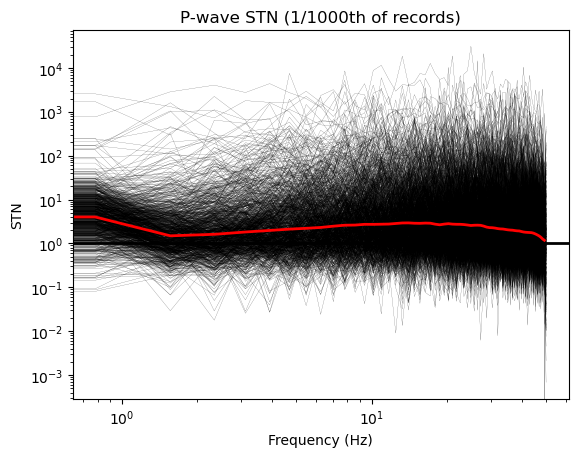

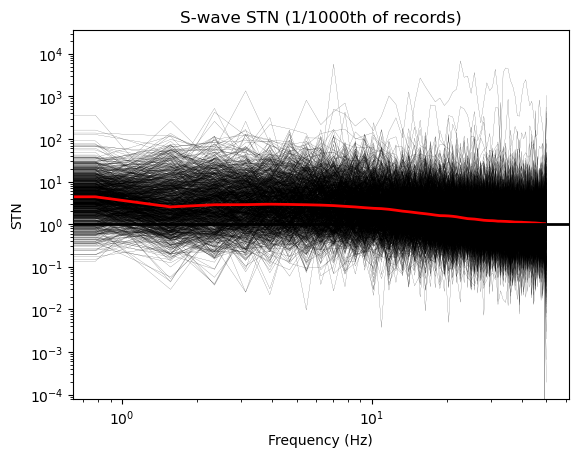

(1027051, 65) (1104043, 65)


In [10]:
# p_stn = p2/p1 
# s_stn = s2/s1

# p_stn_median = np.median(p_stn, axis=0)
# s_stn_median = np.median(s_stn, axis=0)

# plt.figure()
# plt.plot(f, p_stn[::1000,:].T, 'k', linewidth=0.1)
# plt.plot(f, p_stn_median, 'r', linewidth=2)
# plt.yscale('log')
# plt.xscale('log')
# plt.axhline(1, color='k', linewidth=2)
# plt.title("P-wave STN (1/1000th of records)")
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("STN")
# plt.show()

# plt.figure()
# plt.plot(f, s_stn[::1000,:].T, 'k', linewidth=0.1)
# plt.plot(f, s_stn_median, 'r', linewidth=2)
# plt.axhline(1, color='k', linewidth=2)
# plt.yscale('log')
# plt.xscale('log')
# plt.title("S-wave STN (1/1000th of records)")
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("STN")
# plt.show()

# print(p_stn.shape, s_stn.shape)




Visualize the signal-to-noise of the calibration event records

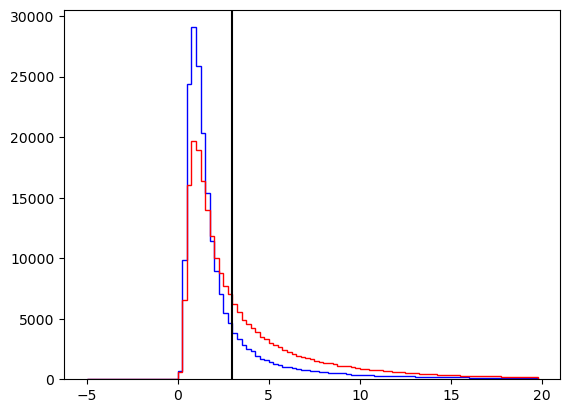

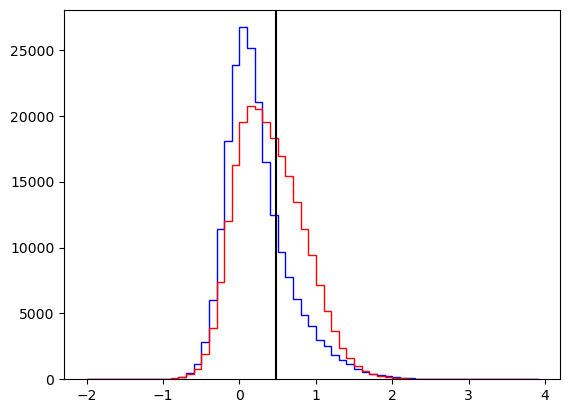

In [11]:
bins = np.arange(-5, 20, 0.25)
logbins = np.arange(-2, 4, 0.1)
df_calib_records = df[np.logical_and(df['qmag'] >= calib_mag_range[0], df['qmag'] < calib_mag_range[1])].reset_index(drop=True)

plt.figure()
plt.hist((df_calib_records['stn_p']), bins=bins, histtype='step', color='b')
plt.hist((df_calib_records['stn_s']), bins=bins, histtype='step', color='r')
plt.axvline(calib_stn_req, color='k')
plt.show()

plt.figure()
plt.hist(np.log10(df_calib_records['stn_p']), bins=logbins, histtype='step', color='b')
plt.hist(np.log10(df_calib_records['stn_s']), bins=logbins, histtype='step', color='r')
plt.axvline(np.log10(calib_stn_req), color='k')
plt.show()



In [12]:
# Setup for big loop
# number of indices in each band
nf_low = 6
# nf_high = 24 
nf_high = 9 

di = 1
dj = 1

# lowest allowed index for each band
if0_low = 1     # 
if0_high = 10   # 

# highest allowed index for each band (inclusive)
if1_low = 9
if1_high = 30

low_f_inds  = [0, nf_low-1] + np.arange(if0_low, if1_low+2-nf_low, di)[:, np.newaxis]
high_f_inds = [0, nf_high-1] + np.arange(if0_high, if1_high+2-nf_high, dj)[:, np.newaxis]

nlow = len(low_f_inds)
nhigh = len(high_f_inds)

N = int(nlow * nhigh)

print(f"{N} combinations of frequency bands")

print("Range of low bands: ", f[low_f_inds[0]], f[low_f_inds[-1]])
print("Range of high bands: ", f[high_f_inds[0]], f[high_f_inds[-1]])
print(low_f_inds)
print(high_f_inds)

# calibration events indices to compute logbeta
df_p_inds = np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0]
df_s_inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]

# calibration events indices to compute logbeta
df_calib_inds_p = np.where([hasattr(el, '__len__') for el in df_calib_records['p2'].values ])[0]
df_calib_inds_s = np.where([hasattr(el, '__len__') for el in df_calib_records['s2'].values ])[0]

dependents += ['logbeta_p', 'logbeta_s']

# Perform corrections using calibration events

if phase == 'p':
    spec = np.vstack(df['p2'].values[df_p_inds], dtype=float)
    df_spec_inds = np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0]
    calib_spec = np.vstack(df_calib_records['p2'].values[df_calib_inds_p], dtype=float)
    df_calib_inds = df_calib_inds_p
elif phase == 's':
    spec = np.vstack(df['s2'].values[df_s_inds], dtype=float)
    df_spec_inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]
    calib_spec = np.vstack(df_calib_records['s2'].values[df_calib_inds_s], dtype=float)
    df_calib_inds = df_calib_inds_s

df_target = df_ev[df_ev['qmag'] >= calib_mag_range[1]].reset_index(drop=True)


# raise ValueError()

corr = np.zeros((nlow, nhigh), dtype=float)
n = 0
for i in range(nlow):
    low_f_ind = low_f_inds[i]
    for j in range(nhigh):
        high_f_ind = high_f_inds[j]

        df_target['dlogbeta'] = 0.0

        # new
        if n == 0:
            df_target['df_c_inds'] = np.zeros(len(df_target), dtype=object)
            df_target['df_inds'] = np.zeros(len(df_target), dtype=object)


        # ## Compute logbeta values for either P- or S-wave spectra
        # if phase=='p':
        #     df['logbeta_p'] = np.nan 
        #     logbeta_p = compute_logbeta(p2, low_f_ind, high_f_ind)
        #     df.loc[df_p_inds, 'logbeta_p'] = logbeta_p
        # elif phase=='s':
        #     df['logbeta_s'] = np.nan 
        #     logbeta_s = compute_logbeta(s2, low_f_ind, high_f_ind)
        #     df.loc[df_s_inds, 'logbeta_s'] = logbeta_s
        df[logbeta_name] = np.nan
        logbeta = compute_logbeta(spec, low_f_ind, high_f_ind)
        df.loc[df_spec_inds, logbeta_name] = logbeta

        df_calib_records[logbeta_name] = np.nan
        logbeta_calib = compute_logbeta(calib_spec, low_f_ind, high_f_ind)
        df_calib_records.loc[df_calib_inds, logbeta_name] = logbeta_calib


        # loop over each target event
        for l in trange(len(df_target), desc=f"{n+1} of {N} iterations: "):

            if n > 0:
                df_target_records = df.iloc[df_target.loc[l, 'df_inds']]

                if hasattr(df_target_records[logbeta_name], '__len__'):
                    target_logbeta = df_target_records[logbeta_name].values
                    calib_logbeta = df_calib_records.iloc[df_target.loc[l, 'df_c_inds']][logbeta_name]

                    dlogbeta = target_logbeta - calib_logbeta
                    df_target.at[l, 'dlogbeta'] = np.median(dlogbeta)
                else:
                    df_target.at[l, 'dlogbeta'] = np.nan
            else:
                # Store the entire row of the target event
                row = df_target.loc[l]

                # Store a copy of the calibration event records DataFrame
                df_c = df_calib_records.copy()

                # Get all records in df relating to target event_id
                df_target_records = df[df['event_id'] == row['event_id']].reset_index(drop=False)

                
                # Filter out calibration event records that:
                #   1) are too shallow or too deep
                #   2) don't share stations with the target event
                #   3) are too low signal-to-noise ratio
                keep_bool = np.all([
                    df_c['qdep']>=row['qdep']-calib_zmax, 
                    df_c['qdep']<=row['qdep']+calib_zmax,
                    np.isin(df_c['stind'].values, row['stind']),
                    df_c[stn_name] >= calib_stn_req,
                    ], axis=0)
                df_c = df_c[keep_bool].reset_index(drop=False)

                # 'index' column in df_c is the index of the calibration event in df_calib_records
                
                # rough filter to avoid computing distances for all calibration events (slightly faster)
                keep_bool = np.all([
                    np.abs(df_c['qx']-row['qx']) <= calib_rmax*1000,
                    np.abs(df_c['qy']-row['qy']) <= calib_rmax*1000,
                ], axis=0)
                df_c = df_c[keep_bool].reset_index(drop=True)

                # compute station-event distance 
                df_c['tdist'] = np.sqrt((row['qx'] - df_c['qx'].values)**2 + (row['qy'] - df_c['qy'].values)**2)

                # filter out calibration events that are too far from the target event
                df_c = df_c[df_c['tdist'] <= calib_rmax*1000].reset_index(drop=True)

                ncalib = len(np.unique(df_c['event_id'].values))

                # added 'index'
                df_c = df_c[['stname','stind', 'event_id', logbeta_name, 'index']]

                if ncalib >= ncalib_min:

                    df_target_records = pd.merge(df_target_records, df_c, how='inner', on='stind', suffixes=['_t','_c'])
                    
                    df_target_records['dlogbeta'] = df_target_records[f'{logbeta_name}_t'] - df_target_records[f'{logbeta_name}_c']

                    df_target.at[l,'dlogbeta'] = np.median(df_target_records['dlogbeta'])

                    # new
                    df_target.at[l,'df_c_inds'] = df_target_records['index_c'].values
                    df_target.at[l, 'df_inds'] = df_target_records['index_t'].values

        ds = df_target[~np.isnan(df_target['dlogbeta'])].reset_index(drop=True)
        ds['dlogbeta_corr'] = ds['dlogbeta'].values

        edges = np.arange(1, 7.3, 0.2)

        for l in range(len(edges)-1):
            inrange = np.logical_and(ds['qmag']>=edges[l], ds['qmag']<edges[l+1])
            if np.sum(inrange) > 0:
                dlogbetas = ds[inrange]['dlogbeta'].values
                ds.loc[inrange, 'dlogbeta_corr'] -= np.nanmedian(dlogbetas)

        # remove records with delsig==0
        ds = ds[ds['delsig'] != 0].reset_index(drop=True)

        corrcoef = np.corrcoef(np.log10(ds['delsig'].values.astype(float)), ds['dlogbeta_corr'].values)[0,1]

        corr[i, j] = corrcoef

        txt = '\n'.join([
            f"correlation: {corrcoef:.4f}", 
            f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
            f"Calib. dmax: {calib_rmax:.1f} km",
            f"Calib. zmax: {calib_zmax:.1f} km",
            f"Calib. STN band:  {stn_f_band[0]:.1f}-{stn_f_band[1]:.1f} Hz",
            f"n calib. minimum: {ncalib_min}",
            f"Low band: {f[low_f_ind[0]]:.1f}-{f[low_f_ind[1]]:.1f} Hz",
            f"High band: {f[high_f_ind[0]]:.1f}-{f[high_f_ind[1]]:.1f} Hz",
        ])

        plt.figure()
        ax = plt.gca()
        plt.scatter(ds['delsig'], ds['dlogbeta_corr'], c=ds['qmag'], s=3, marker='.')
        plt.xscale('log')
        plt.ylim([-0.8, 0.8])
        plt.xlim([0.5, 5000.0])
        ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
        plt.xlabel('Stress drop (MPa)')
        plt.ylabel('Corrected logbeta')
        plt.savefig(f"figs/corr/{n}_{phase}_correlation.pdf")
        # plt.show()
        plt.close()


        n += 1
np.save(f'data/corr_{phase}.npy', corr)

52 combinations of frequency bands
Range of low bands:  [0.78125 4.6875 ] [3.125   7.03125]
Range of high bands:  [ 7.8125 14.0625] [17.1875 23.4375]
[[1 6]
 [2 7]
 [3 8]
 [4 9]]
[[10 18]
 [11 19]
 [12 20]
 [13 21]
 [14 22]
 [15 23]
 [16 24]
 [17 25]
 [18 26]
 [19 27]
 [20 28]
 [21 29]
 [22 30]]


52 of 52 iterations: 100%|██████████| 6777/6777 [00:27<00:00, 248.75it/s]


[0] [12]


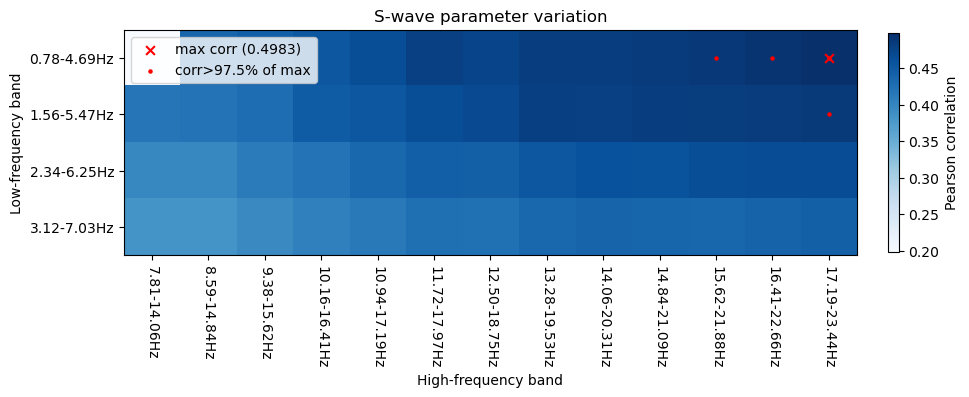

['7.81-14.06Hz', '8.59-14.84Hz', '9.38-15.62Hz', '10.16-16.41Hz', '10.94-17.19Hz', '11.72-17.97Hz', '12.50-18.75Hz', '13.28-19.53Hz', '14.06-20.31Hz', '14.84-21.09Hz', '15.62-21.88Hz', '16.41-22.66Hz', '17.19-23.44Hz']


In [13]:
pct = 0.975

xlabel_ticks = np.arange(0, corr.shape[1], 1)
xlabels = [f"{f[high_f_inds[el][0]]:.2f}-{f[high_f_inds[el][1]]:.2f}Hz" for el in xlabel_ticks]

ylabel_ticks = np.arange(0, corr.shape[0], 1)
ylabels = [f"{f[low_f_inds[el][0]]:.2f}-{f[low_f_inds[el][1]]:.2f}Hz" for el in ylabel_ticks]

high_inds = np.where(corr >= pct*np.max(corr))

imax, jmax = np.where(corr == np.max(corr))
print(imax, jmax)
plt.figure(figsize=(10,10))
ax = plt.gca()
im = plt.imshow(corr, cmap='Blues')
plt.scatter(jmax, imax, marker='x', color='red', s=40, label=f"max corr ({corr[imax, jmax][0]:.4f})")
plt.scatter(high_inds[1], high_inds[0], marker='o', color='red', s=5, label=f"corr>{100*pct:.1f}% of max")
cbar = plt.colorbar(im, fraction=0.046*corr.shape[0]/corr.shape[1], pad=0.04)
lbl = ax.get_xticklabels()
plt.xlabel("High-frequency band")
plt.ylabel("Low-frequency band")
ax.set_xticks(xlabel_ticks)
ax.set_xticklabels(xlabels)
plt.xticks(rotation=-90)

ax.set_yticks(ylabel_ticks)
ax.set_yticklabels(ylabels)

cbar.ax.set_ylabel("Pearson correlation")
plt.legend()
plt.title(f"{phase.upper()}-wave parameter variation")
plt.savefig(f'figs/corr/all_{phase}_correlation.pdf', bbox_inches='tight')
plt.show()

print(xlabels)

In [14]:
corr

array([[0.1981149 , 0.43698038, 0.44324422, 0.45341438, 0.46422378,
        0.47926299, 0.47382861, 0.48127446, 0.48071809, 0.48455113,
        0.48842263, 0.49253815, 0.49826087],
       [0.41839038, 0.42014817, 0.42762764, 0.44713734, 0.45316765,
        0.46363237, 0.46819082, 0.47960723, 0.47876001, 0.48179529,
        0.48207856, 0.48392348, 0.48708303],
       [0.39793645, 0.39857647, 0.41107323, 0.42085436, 0.43392469,
        0.44366754, 0.44253921, 0.45337303, 0.45994358, 0.45743151,
        0.46389099, 0.46447782, 0.46492733],
       [0.38249233, 0.3832193 , 0.39438151, 0.40543058, 0.41370686,
        0.42493746, 0.42328428, 0.43424386, 0.43798028, 0.43708773,
        0.4353225 , 0.43894371, 0.44312027]])

In [15]:
corr

array([[0.1981149 , 0.43698038, 0.44324422, 0.45341438, 0.46422378,
        0.47926299, 0.47382861, 0.48127446, 0.48071809, 0.48455113,
        0.48842263, 0.49253815, 0.49826087],
       [0.41839038, 0.42014817, 0.42762764, 0.44713734, 0.45316765,
        0.46363237, 0.46819082, 0.47960723, 0.47876001, 0.48179529,
        0.48207856, 0.48392348, 0.48708303],
       [0.39793645, 0.39857647, 0.41107323, 0.42085436, 0.43392469,
        0.44366754, 0.44253921, 0.45337303, 0.45994358, 0.45743151,
        0.46389099, 0.46447782, 0.46492733],
       [0.38249233, 0.3832193 , 0.39438151, 0.40543058, 0.41370686,
        0.42493746, 0.42328428, 0.43424386, 0.43798028, 0.43708773,
        0.4353225 , 0.43894371, 0.44312027]])

In [16]:


# compute widths of each cross section
A_len = np.sqrt(np.sum(np.power(Ap - A, 2)))
B_len = np.sqrt(np.sum(np.power(Bp - B, 2)))
A_ratio = A_len / (A_len + B_len)
B_ratio = B_len / (A_len + B_len)
gridspec_kw = {"width_ratios": [A_ratio, B_ratio]}



In [17]:

# plot the map-view and cross-sections of stress drop from Shearer et 
# al. (2022) for reference




df_plot = df_target # [df_target['qmag']>=2.0]
df_plot['easting'] = df_plot['qx']
df_plot['northing'] = df_plot['qy']
# df_plot = df_ev[np.logical_and(df_ev['qmag']>=1.6, df_ev['qmag']<1.8)]
# df_plot = df_ev[df_ev['qdep']<=1.0]
# df_plot = df_ev

dataname = 'dlogbeta_corr'
datatitle = r"dlogbeta"

cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='mediancenter')

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 8.5),
    layout='constrained')
mapout = mt.plot_map(
    df_plot,
    ax=ax,
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

mt.plot_xsection_line(A, Ap, ax, labels=["A", "A'"], linewidth=2, 
    exact_tick_length=xsec_dmax)
mt.plot_xsection_line(B, Bp, ax, labels=["B", "B'"], linewidth=2, 
    exact_tick_length=xsec_dmax)


cb_ax = fig.add_axes([1.0,.080,.028,.85])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
smap.set_clim([cnorm.vmin, cnorm.vmax])

cbar.ax.set_ylabel(datatitle)
fig.suptitle(datatitle)



fig, [ax1, ax2] = plt.subplots(nrows=1, ncols=2, figsize=(11, 4),
    sharey='all', sharex='col', gridspec_kw=gridspec_kw, layout='constrained')


importlib.reload(mt)
xsecoutA = mt.plot_xsection(
    df_plot, 
    p1 = A, 
    p2 = Ap, 
    max_dist = xsec_dmax,
    ax=ax1, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    )

xsecoutB = mt.plot_xsection(
    df_plot, 
    p1 = B, 
    p2 = Bp, 
    max_dist = xsec_dmax,
    ax=ax2, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    line_name="B"
    )


fig.supylabel("Depth (km)")
fig.supxlabel("Distance along strike (km)", x=0.63)
fig.suptitle(datatitle)

# colorbar
cb_ax = fig.add_axes([1.0,.085,.02,.83])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
# smap.set_clim(clim)
# cbar.ax.set_yticks(cticks)
# cbar.ax.set_yticklabels(clabels)
cbar.ax.set_ylabel(datatitle)

# fig.canvas.draw_idle()

plt.show()




KeyError: 'dlogbeta_corr'